# lstm-2 — Full Pipeline Walkthrough

This notebook walks through every step of the lstm-2 machine-learning pipeline: raw bar data → feature engineering → target definition → data cleaning → train/val/test split → scaling → sliding-window construction → model architecture → training loop → evaluation.

Each section has:
- **Definition** — what the step is and why it exists
- **Example settings** — the knobs you can turn
- **Runnable cells** — pandas tables and Plotly charts showing the real data

---
**Launch from the project root so imports resolve:**
```bash
source .venv/bin/activate
pip install notebook yfinance plotly   # one-time, does not touch pyproject.toml
jupyter notebook notebooks/lstm2_pipeline.ipynb
```

In [1]:
import sys, pathlib

root = pathlib.Path.cwd()
# If launched from a subdirectory, walk up until we find src/
for p in [root, *root.parents]:
    if (p / 'src').exists():
        root = p
        break

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print('Project root:', root)
print('Python:', sys.version)

Project root: /Volumes/My SSD/Chris Stuff/DEV/lstm_2
Python: 3.12.12 (main, Dec 17 2025, 21:21:06) [Clang 21.1.4 ]


---
## §1 — OHLCV Bar Data

**What is a bar?**  
A *bar* (also called a *candlestick*) represents all price activity in one time period:
- **Open** — first trade price of the period
- **High** — highest trade price
- **Low** — lowest trade price
- **Close** — last trade price
- **Volume** — number of shares/units traded

**Why is this the foundation?**  
Every technical indicator and every prediction target is derived from these five columns. Raw OHLCV is the only input the model ultimately needs.

**In this project:**  
Bars are fetched from Alpaca and stored in MariaDB. For this notebook we use `yfinance` (free, no API key) which returns the same five columns.

**Timeframe choices:** `1m`, `5m`, `15m`, `1h`, `1d`, `1wk`  
More bars per day = more data but slower training and noisier signals.

In [2]:
# ── Example settings ──────────────────────────────────────────────────────────
SYMBOL    = 'AAPL'   # ticker symbol
PERIOD    = '3y'     # how far back to fetch  ('1y', '2y', '5y', 'max')
TIMEFRAME = '1d'     # bar interval           ('1d', '1h', '5m', etc.)
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
import yfinance as yf
import pandas as pd

raw = yf.Ticker(SYMBOL).history(period=PERIOD, interval=TIMEFRAME)
raw = raw.rename(columns=str.lower)[['open', 'high', 'low', 'close', 'volume']].dropna()
raw.index = raw.index.tz_localize(None)   # strip timezone for cleaner display
raw.index.name = 'timestamp_utc'
df_raw = raw.reset_index()

print(f'Symbol: {SYMBOL}  |  Bars: {len(df_raw):,}  |  '
      f'{df_raw["timestamp_utc"].min().date()} → {df_raw["timestamp_utc"].max().date()}')
display(df_raw.head(10).style.format(
    {'open': '{:.2f}', 'high': '{:.2f}', 'low': '{:.2f}', 'close': '{:.2f}', 'volume': '{:,.0f}'}
))

Symbol: AAPL  |  Bars: 752  |  2023-06-09 → 2026-06-09


,timestamp_utc,open,high,low,close,volume
0,2023-06-09 00:00:00,178.99,179.71,178.13,178.46,"48,900,000"
1,2023-06-12 00:00:00,178.76,181.35,178.47,181.25,"54,274,900"
2,2023-06-13 00:00:00,180.27,181.60,179.92,180.78,"54,929,100"
3,2023-06-14 00:00:00,180.83,181.84,179.50,181.41,"57,462,900"
4,2023-06-15 00:00:00,181.42,183.94,181.24,183.44,"65,433,200"
5,2023-06-16 00:00:00,184.15,184.40,181.72,182.36,"101,256,200"
6,2023-06-20 00:00:00,181.86,183.53,181.86,182.45,"49,799,100"
7,2023-06-21 00:00:00,182.34,182.85,180.07,181.42,"49,515,700"
8,2023-06-22 00:00:00,181.20,184.46,181.13,184.41,"51,245,300"
9,2023-06-23 00:00:00,182.98,184.97,182.45,184.10,"53,117,000"


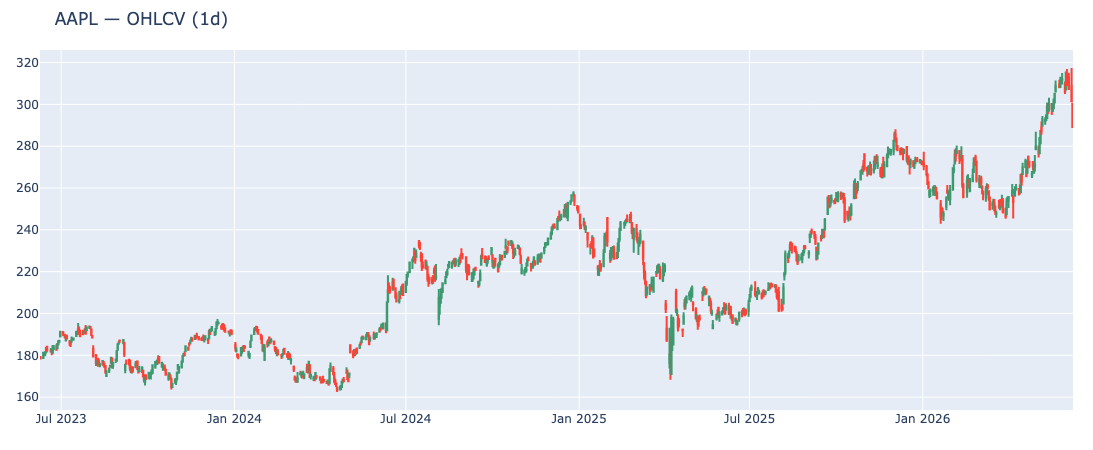

In [4]:
import plotly.graph_objects as go

fig = go.Figure(go.Candlestick(
    x=df_raw['timestamp_utc'],
    open=df_raw['open'],
    high=df_raw['high'],
    low=df_raw['low'],
    close=df_raw['close'],
    name=SYMBOL,
))
fig.update_layout(
    title=f'{SYMBOL} — OHLCV ({TIMEFRAME})',
    xaxis_rangeslider_visible=False,
    height=450,
    margin=dict(l=40, r=20, t=50, b=40),
)
fig.show()

---
## §2 — Technical Indicator Features

**Why not use raw OHLCV directly as model input?**  
The LSTM could theoretically learn from raw prices, but it would need to discover patterns like momentum, volatility regimes, and trend direction from scratch. Technical indicators pre-compute these patterns, giving the model a head start.

**The project has 100 indicators across 6 categories:**

| Category | What it captures |
|---|---|
| **Trend** | Direction of price movement (SMAs, EMAs, Ichimoku) |
| **Momentum** | Speed of price change (RSI, MACD, Stochastic) |
| **Volatility** | Size of price swings (ATR, Bollinger Bands, Keltner) |
| **Volume** | Buying/selling pressure (OBV, VWAP, A/D Line) |
| **Trend Strength** | How strong the trend is (ADX, Vortex) |
| **Price Action** | Statistical properties of price (returns, z-score) |

**NaN warmup:**  
The SMA-200 needs 200 bars before it can produce a value. All rows before that have `NaN`. We drop them later in §4.

In [5]:
from src.api.features.indicators import compute, INDICATOR_KEYS, INDICATOR_META

# Catalogue — all 100 indicators, grouped by category
meta_df = pd.DataFrame([
    {'key': k, 'label': v['label'], 'category': v['category'], 'description': v['desc']}
    for k, v in INDICATOR_META.items()
])
print(f'Total indicators: {len(meta_df)}')
display(meta_df.groupby('category').size().rename('count').to_frame())
display(meta_df.head(20))

Total indicators: 100


,count
category,
Momentum,20
Price Action,18
Trend,20
Trend Strength,10
Volatility,18
Volume,14


,key,label,category,description
0,sma_5,SMA 5,Trend,"Simple moving average, 5 periods"
1,sma_10,SMA 10,Trend,"Simple moving average, 10 periods"
2,sma_20,SMA 20,Trend,"Simple moving average, 20 periods"
3,sma_50,SMA 50,Trend,"Simple moving average, 50 periods"
4,sma_200,SMA 200,Trend,"Simple moving average, 200 periods"
5,ema_5,EMA 5,Trend,"Exponential moving average, 5 periods"
6,ema_10,EMA 10,Trend,"Exponential moving average, 10 periods"
7,ema_20,EMA 20,Trend,"Exponential moving average, 20 periods"
8,ema_50,EMA 50,Trend,"Exponential moving average, 50 periods"
9,ema_200,EMA 200,Trend,"Exponential moving average, 200 periods"


In [6]:
# ── Example settings ──────────────────────────────────────────────────────────
DEMO_INDICATOR_KEYS = ['sma_20', 'sma_50', 'ema_20', 'rsi_14', 'macd',
                       'atr_14', 'bb_upper', 'bb_mid', 'bb_lower', 'obv']
# Use INDICATOR_KEYS to compute ALL 100 (needed for §4 onward)
# ─────────────────────────────────────────────────────────────────────────────

# compute() expects a DataFrame with columns: open, high, low, close, volume
ohlcv = df_raw.set_index('timestamp_utc')[['open', 'high', 'low', 'close', 'volume']]
demo_indicators = compute(ohlcv, DEMO_INDICATOR_KEYS)

df_feat = df_raw.copy()
for k, series in demo_indicators.items():
    df_feat[k] = series.values

# NaN warmup per indicator
nan_counts = df_feat[DEMO_INDICATOR_KEYS].isna().sum().rename('nan_warmup_rows')
display(nan_counts.to_frame())

print('\nLast 10 rows (indicators should all have values):')
display(df_feat[['timestamp_utc', 'close'] + DEMO_INDICATOR_KEYS].tail(10).round(4))

,nan_warmup_rows
sma_20,19
sma_50,49
ema_20,0
rsi_14,2
macd,0
atr_14,0
bb_upper,19
bb_mid,19
bb_lower,19
obv,0



Last 10 rows (indicators should all have values):


/var/folders/y6/zdm_tlhd2133y753fwjlh3r40000gn/T/ipykernel_90794/687001959.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(df_feat[['timestamp_utc', 'close'] + DEMO_INDICATOR_KEYS].tail(10).round(4))


,timestamp_utc,close,sma_20,sma_50,ema_20,rsi_14,macd,atr_14,bb_upper,bb_mid,bb_lower,obv
742,2026-05-27,310.85,293.2854,272.6920,294.6231,85.5117,10.3343,5.4496,317.6142,293.2854,268.9566,2.598002e+09
743,2026-05-28,312.51,295.4148,273.8623,296.3267,86.8536,10.4880,5.1537,318.5597,295.4148,272.2700,2.646222e+09
744,2026-05-29,312.06,297.4628,275.1093,297.8251,84.4081,10.4529,5.1958,318.7205,297.4628,276.2052,2.576195e+09
745,2026-06-01,306.31,298.7842,276.2609,298.6332,59.6477,9.8476,5.4417,318.6826,298.7842,278.8858,2.527345e+09
746,2026-06-02,315.20,300.7155,277.6096,300.2110,73.5101,9.9703,5.9348,318.9674,300.7155,282.4635,2.571880e+09
747,2026-06-03,310.26,302.0325,278.7897,301.1680,60.2412,9.5588,6.2222,318.9325,302.0325,285.1325,2.521043e+09
748,2026-06-04,311.23,303.2318,279.9861,302.1263,61.8033,9.2048,5.9112,319.0852,303.2318,287.3784,2.565912e+09
749,2026-06-05,307.34,304.2400,281.0852,302.6228,52.2957,8.5123,6.1924,318.2517,304.2400,290.2283,2.500602e+09
750,2026-06-08,301.54,304.6645,282.0628,302.5197,41.3518,7.4100,7.5307,317.7313,304.6645,291.5977,2.422871e+09
751,2026-06-09,289.16,304.4885,282.8746,301.2474,27.2876,5.4743,8.2280,318.3082,304.4885,290.6689,2.388625e+09


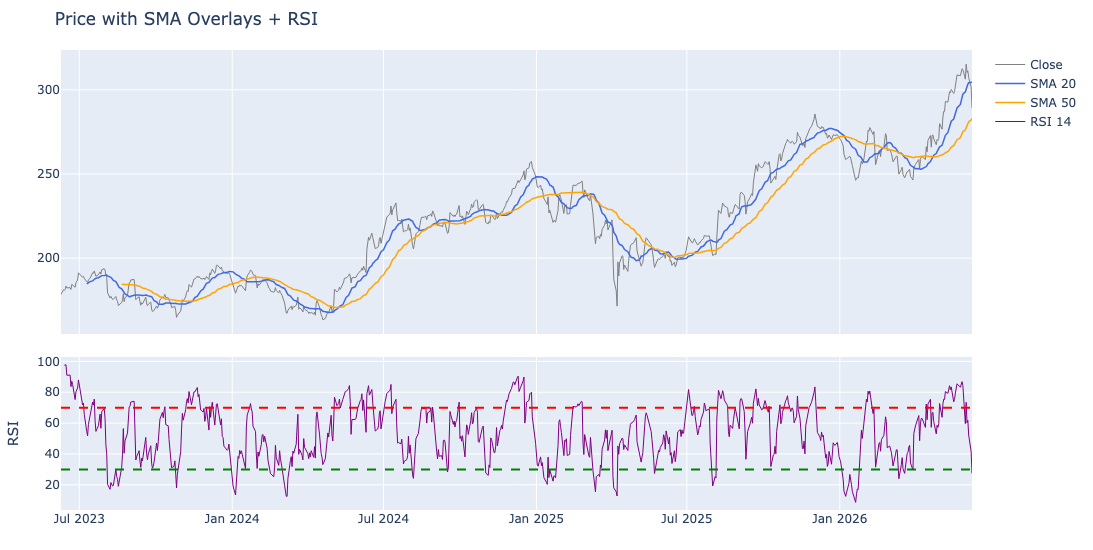

In [7]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.35], vertical_spacing=0.05)

# Price + SMA overlays
fig.add_trace(go.Scatter(x=df_feat['timestamp_utc'], y=df_feat['close'],
                          name='Close', line=dict(color='gray', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=df_feat['timestamp_utc'], y=df_feat['sma_20'],
                          name='SMA 20', line=dict(color='royalblue', width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=df_feat['timestamp_utc'], y=df_feat['sma_50'],
                          name='SMA 50', line=dict(color='orange', width=1.5)), row=1, col=1)

# RSI sub-pane
fig.add_trace(go.Scatter(x=df_feat['timestamp_utc'], y=df_feat['rsi_14'],
                          name='RSI 14', line=dict(color='purple', width=1)), row=2, col=1)
fig.add_hline(y=70, line_dash='dash', line_color='red',   row=2, col=1)
fig.add_hline(y=30, line_dash='dash', line_color='green', row=2, col=1)

fig.update_layout(title='Price with SMA Overlays + RSI', height=550,
                  margin=dict(l=40, r=20, t=50, b=40))
fig.update_yaxes(title_text='RSI', row=2, col=1)
fig.show()

---
## §3 — Prediction Targets

**What is a target?**  
The value the model is trained to predict. Every target is derived from future bar data — the model sees bars up to time `t` and predicts something about bar `t+1` (or further ahead).

**`shift=-1`** means *shift the source column backward by 1*, which aligns the future value with the current row. This is how "predict the next bar" is expressed.

**Task types:**

| Task type | Output | Loss | Example |
|---|---|---|---|
| **classification** | 0 or 1 (binary) | BCE | Will price go up next bar? |
| **regression** | continuous float | MSE/MAE | What will the return be? |

**Derived target types available in the project:**
- `direction` — 1 if next close > current close, else 0
- `return_pct` — percentage change to next close
- `return_frac` — fractional change (price-agnostic)
- `log_return` — log of price ratio (normally distributed)
- `realized_vol` — rolling standard deviation of returns (volatility target)
- `large_move` — 1 if |return| exceeds a threshold
- `breakout` — 1 if price breaks above/below N-bar high/low

In [8]:
# ── Example settings ──────────────────────────────────────────────────────────
# Classification: predict if next bar closes higher than current bar
TARGET_LABEL   = 'direction'
TARGET_SOURCE  = 'close'
TARGET_SHIFT   = -1        # -1 = predict 1 bar ahead
TARGET_TYPE    = 'classification'   # 'classification' or 'regression'
TARGET_DERIVED = 'direction'        # derived transform to apply

# For a return regression instead, use:
#   TARGET_LABEL='return_pct', TARGET_TYPE='regression', TARGET_DERIVED='return_pct'
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

def apply_target(df, source_col, shift, derived):
    """Compute a target column from source_col and add to df."""
    s = df[source_col]
    future = s.shift(shift)   # shift=-1 → next bar's value aligned to current row
    if derived == 'direction':
        return (future > s).astype(float)
    elif derived == 'return_pct':
        return (future - s) / s * 100
    elif derived == 'return_frac':
        return (future - s) / s
    elif derived == 'log_return':
        return np.log(future / s)
    else:
        return future   # direct shift, no transform

df_feat[TARGET_LABEL] = apply_target(df_feat, TARGET_SOURCE, TARGET_SHIFT, TARGET_DERIVED)

sample = df_feat[['timestamp_utc', TARGET_SOURCE, TARGET_LABEL]].dropna().tail(15)
display(sample.style.format({TARGET_SOURCE: '{:.2f}', TARGET_LABEL: '{:.0f}'}))

dist = df_feat[TARGET_LABEL].value_counts().rename_axis('value').reset_index(name='count')
dist['%'] = (dist['count'] / dist['count'].sum() * 100).round(1)
print('\nTarget distribution:')
display(dist)

,timestamp_utc,close,direction
737,2026-05-19 00:00:00,298.97,1
738,2026-05-20 00:00:00,302.25,1
739,2026-05-21 00:00:00,304.99,1
740,2026-05-22 00:00:00,308.82,0
741,2026-05-26 00:00:00,308.33,1
742,2026-05-27 00:00:00,310.85,1
743,2026-05-28 00:00:00,312.51,0
744,2026-05-29 00:00:00,312.06,0
745,2026-06-01 00:00:00,306.31,1
746,2026-06-02 00:00:00,315.20,0



Target distribution:


,value,count,%
0,1.0,407,54.1
1,0.0,345,45.9


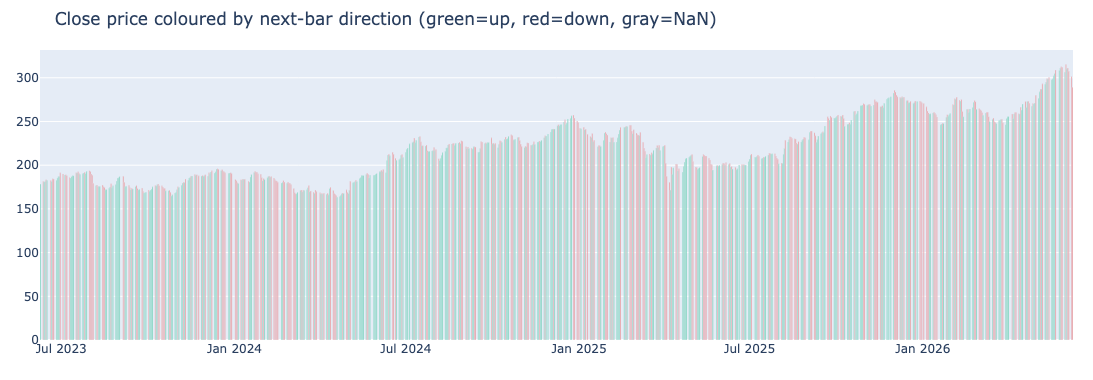

In [9]:
# Price bar coloured by the next-bar target label
color_map = {1.0: 'rgba(16,185,129,0.7)', 0.0: 'rgba(239,68,68,0.7)'}
colors = df_feat[TARGET_LABEL].map(color_map).fillna('rgba(150,150,150,0.4)')

fig = go.Figure(go.Bar(
    x=df_feat['timestamp_utc'],
    y=df_feat[TARGET_SOURCE],
    marker_color=colors,
    name='Close',
))
fig.update_layout(
    title='Close price coloured by next-bar direction (green=up, red=down, gray=NaN)',
    height=380,
    margin=dict(l=40, r=20, t=50, b=40),
    bargap=0,
)
fig.show()

---
## §4 — Data Cleaning (NaN Strategy)

**Why do NaNs exist?**
1. **Indicator warmup** — the longest MA (SMA-200) needs 200 bars before it produces a value. All rows before bar 200 have `NaN` for that indicator.
2. **Target shift** — a `shift=-1` target has `NaN` in the last row (there is no "next bar" yet).

**Strategy: `drop`**  
Remove any row with at least one `NaN`. This is the only viable approach for sequence models — you cannot fill future-looking NaNs with forward-fill without introducing data leakage, and the LSTM expects clean contiguous sequences.

**Data retained:**  
With 3 years of daily bars (~750 rows) and SMA-200 as the longest indicator, you lose ~200 rows (27%) and train on ~550 clean rows. With intraday data (e.g. 1 min bars over 2 years) you'd have 200k+ rows and lose the same 200 warmup rows — effectively zero loss.

In [10]:
# Compute ALL 100 indicators (needed for the full pipeline)
all_indicators = compute(ohlcv, list(INDICATOR_KEYS))
df_full = df_raw.copy()
for k, series in all_indicators.items():
    df_full[k] = series.values
df_full[TARGET_LABEL] = apply_target(df_full, TARGET_SOURCE, TARGET_SHIFT, TARGET_DERIVED)

before = len(df_full)
nan_per_col = df_full.isna().sum()
df_clean = df_full.dropna().reset_index(drop=True)
after = len(df_clean)

summary = pd.DataFrame([
    {'stage': 'Raw bars',   'rows': before, 'rows_dropped': 0},
    {'stage': 'After drop', 'rows': after,  'rows_dropped': before - after},
])
display(summary)
print(f'Data retained: {after / before * 100:.1f}%')

print('\nTop NaN contributors (columns with the most warmup NaNs):')
top_nan = nan_per_col[nan_per_col > 0].sort_values(ascending=False).head(10)
display(top_nan.rename('nan_rows').to_frame())

/var/folders/y6/zdm_tlhd2133y753fwjlh3r40000gn/T/ipykernel_90794/858865123.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full[k] = series.values
/var/folders/y6/zdm_tlhd2133y753fwjlh3r40000gn/T/ipykernel_90794/858865123.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full[TARGET_LABEL] = apply_target(df_full, TARGET_SOURCE, TARGET_SHIFT, TARGET_DERIVED)


,stage,rows,rows_dropped
0,Raw bars,752,0
1,After drop,553,199


Data retained: 73.5%

Top NaN contributors (columns with the most warmup NaNs):


,nan_rows
sma_200,199
sma_50,49
pct_rank_50,49
dpo_20,30
ichimoku_base,25
aroon_up,25
aroon_down,25
aroon_osc,25
mass_index,24
hma_20,22


---
## §5 — Train / Val / Test Split

**Why temporal split, not random?**  
In time-series forecasting, shuffling and splitting randomly would leak future information into training — a bar from 2024 in the training set would "teach" the model about market conditions it should be predicting in the test set. The split must be chronological: train comes first, then val, then test.

**What each split is used for:**
- **Train (70%)** — the model optimises its weights on this data
- **Val (15%)** — monitored during training for early stopping; used to pick the best model checkpoint
- **Test (15%)** — held out entirely until after training; the only unbiased measure of real performance

**Typical ratios:** 70/15/15 or 80/10/10. With smaller datasets, use 80/10/10 to keep more training data.

In [11]:
# ── Example settings ──────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
# ─────────────────────────────────────────────────────────────────────────────

n = len(df_clean)
train_end = int(n * TRAIN_RATIO)
val_end   = train_end + int(n * VAL_RATIO)

train_df = df_clean.iloc[:train_end].reset_index(drop=True)
val_df   = df_clean.iloc[train_end:val_end].reset_index(drop=True)
test_df  = df_clean.iloc[val_end:].reset_index(drop=True)

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'pct': f'{len(train_df)/n*100:.0f}%',
     'start': str(train_df['timestamp_utc'].iloc[0].date()),
     'end':   str(train_df['timestamp_utc'].iloc[-1].date())},
    {'split': 'val',   'rows': len(val_df),   'pct': f'{len(val_df)/n*100:.0f}%',
     'start': str(val_df['timestamp_utc'].iloc[0].date()),
     'end':   str(val_df['timestamp_utc'].iloc[-1].date())},
    {'split': 'test',  'rows': len(test_df),  'pct': f'{len(test_df)/n*100:.0f}%',
     'start': str(test_df['timestamp_utc'].iloc[0].date()),
     'end':   str(test_df['timestamp_utc'].iloc[-1].date())},
])
display(split_summary)

,split,rows,pct,start,end
0,train,387,70%,2024-03-26,2025-10-09
1,val,82,15%,2025-10-10,2026-02-06
2,test,84,15%,2026-02-09,2026-06-09


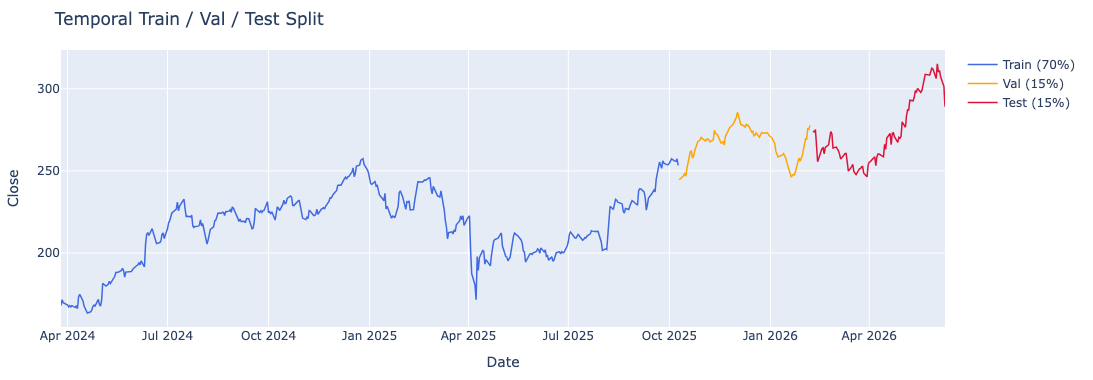

In [12]:
fig = go.Figure()
for df_s, name, color in [
    (train_df, 'Train (70%)', 'royalblue'),
    (val_df,   'Val (15%)',   'orange'),
    (test_df,  'Test (15%)',  'crimson'),
]:
    fig.add_trace(go.Scatter(
        x=df_s['timestamp_utc'], y=df_s['close'],
        name=name, line=dict(color=color, width=1.5),
    ))
fig.update_layout(
    title='Temporal Train / Val / Test Split',
    xaxis_title='Date', yaxis_title='Close',
    height=380, margin=dict(l=40, r=20, t=50, b=40),
)
fig.show()

---
## §6 — Feature Scaling

**Why scale?**  
Neural network gradient descent is sensitive to feature magnitude. Without scaling, a feature like `volume` (~10M) drowns out `rsi_14` (~50), and the optimizer either ignores the small features or gets stuck on the large ones.

**Scalers available:**

| Scaler | Formula | Best for |
|---|---|---|
| `standard` | `(x − μ) / σ` — zero mean, unit variance | General purpose; most common |
| `minmax` | `(x − min) / (max − min)` → [0, 1] | Bounded inputs; known range |
| `robust` | `(x − median) / IQR` | Data with outliers (e.g. volume spikes) |

**Critical rule:** fit the scaler ONLY on the training set, then apply the same transform to val and test. Fitting on all data would leak future statistics (e.g. the global max) into training — a subtle form of data leakage.

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

_SCALERS = {'standard': StandardScaler, 'minmax': MinMaxScaler, 'robust': RobustScaler}

# ── Example settings ──────────────────────────────────────────────────────────
SCALER_TYPE = 'standard'   # 'standard' | 'minmax' | 'robust'
# ─────────────────────────────────────────────────────────────────────────────

# Feature columns = everything except timestamp and the target
FEATURE_COLS = [c for c in df_clean.columns if c not in ('timestamp_utc', TARGET_LABEL)]
print(f'{len(FEATURE_COLS)} feature columns')

scaler = _SCALERS[SCALER_TYPE]()
train_feat = scaler.fit_transform(train_df[FEATURE_COLS].values.astype('float64'))   # fit + transform
val_feat   = scaler.transform(val_df[FEATURE_COLS].values.astype('float64'))          # transform only
test_feat  = scaler.transform(test_df[FEATURE_COLS].values.astype('float64'))         # transform only

# Before vs after for the first 6 features
display_cols = FEATURE_COLS[:6]
idx = [FEATURE_COLS.index(c) for c in display_cols]
before = pd.DataFrame(train_df[display_cols].values[:5], columns=display_cols)
after  = pd.DataFrame(train_feat[:5][:, idx], columns=display_cols)
print('Before scaling (first 5 rows, first 6 features):')
display(before.round(4))
print(f'After {SCALER_TYPE} scaling:')
display(after.round(4))

105 feature columns
Before scaling (first 5 rows, first 6 features):


,open,high,low,close,volume,sma_5
0,168.3118,169.7177,167.8959,168.0246,57388400.0,170.8622
1,168.7177,171.8760,168.4206,171.5889,60273300.0,169.8008
2,170.0444,170.5196,168.8167,169.7770,65672700.0,169.8226
3,169.4899,169.5493,167.7969,168.3414,46240500.0,169.3771
4,167.4009,167.6583,166.5593,167.1633,49329500.0,168.9790


After standard scaling:


,open,high,low,close,volume,sma_5
0,-2.2075,-2.2612,-2.1397,-2.2279,0.0430,-2.1003
1,-2.1888,-2.1615,-2.1154,-2.0642,0.1427,-2.1496
2,-2.1277,-2.2241,-2.0971,-2.1474,0.3295,-2.1486
3,-2.1532,-2.2690,-2.1442,-2.2133,-0.3426,-2.1693
4,-2.2494,-2.3564,-2.2015,-2.2675,-0.2358,-2.1877


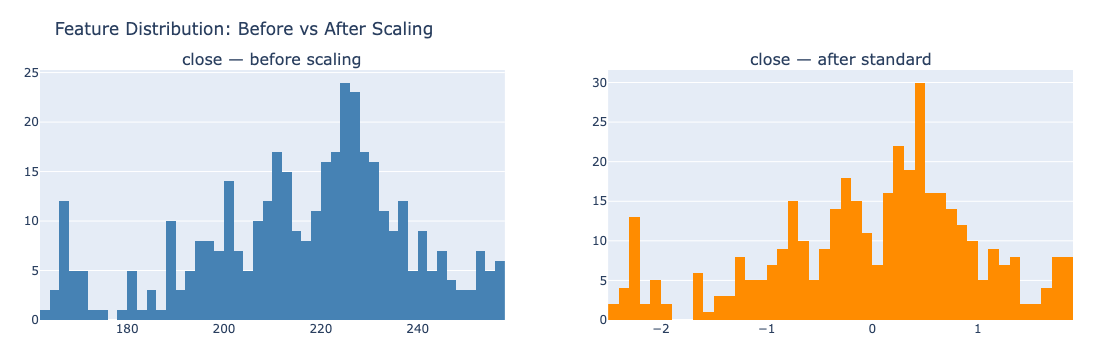

In [14]:
import plotly.express as px
from plotly.subplots import make_subplots

# Distribution of 'close' before and after scaling
feat_idx = FEATURE_COLS.index('close')
raw_vals   = train_df['close'].values
scaled_vals = train_feat[:, feat_idx]

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['close — before scaling', f'close — after {SCALER_TYPE}'])
fig.add_trace(go.Histogram(x=raw_vals,    nbinsx=50, marker_color='steelblue'), row=1, col=1)
fig.add_trace(go.Histogram(x=scaled_vals, nbinsx=50, marker_color='darkorange'), row=1, col=2)
fig.update_layout(title='Feature Distribution: Before vs After Scaling',
                  showlegend=False, height=360, margin=dict(l=40, r=20, t=70, b=40))
fig.show()

---
## §7 — Sliding Window (Lookback / Sequence Construction)

**Why does an LSTM need sequences?**  
An LSTM maintains a hidden state that carries information across timesteps. To use this, each training sample must be a *sequence* of consecutive bars — not a single row.

**What is `lookback`?**  
The number of past bars in each sample. With `lookback=20`, each sample is a 2D matrix: `(20 bars × n_features)`. The model sees the last 20 bars and predicts the target of bar 21.

**Window sliding:**
```
bars:  [0, 1, 2, ..., N]
X[0]:  bars[0..19]   → y[0] = target at bar 20
X[1]:  bars[1..20]   → y[1] = target at bar 21
  ...
X[N-20]: bars[N-20..N-1] → y[N-20] = target at bar N
```
Total samples = N − lookback.

**Choosing `lookback`:**  
- Too small (< 10): model can't see patterns that span multiple bars  
- Too large (> 100): longer training, risk of vanishing gradient, may not help  
- Typical range: 20–60 bars

In [16]:
import torch

# ── Example settings ──────────────────────────────────────────────────────────
LOOKBACK   = 20    # number of past bars per sample
BATCH_SIZE = 32
# ─────────────────────────────────────────────────────────────────────────────

def make_windows(features, targets, lookback):
    """Construct (X, y) tensors from scaled feature and target arrays."""
    n = len(features)
    if n <= lookback:
        raise ValueError(f'Not enough rows ({n}) for lookback={lookback}')
    X = np.array([features[i:i + lookback] for i in range(n - lookback)], dtype='float32')
    y = targets[lookback:].astype('float32')
    return torch.tensor(X), torch.tensor(y)

y_train_arr = train_df[[TARGET_LABEL]].values
y_val_arr   = val_df[[TARGET_LABEL]].values
y_test_arr  = test_df[[TARGET_LABEL]].values

X_train, y_train = make_windows(train_feat, y_train_arr, LOOKBACK)
X_val,   y_val   = make_windows(val_feat,   y_val_arr,   LOOKBACK)
X_test,  y_test  = make_windows(test_feat,  y_test_arr,  LOOKBACK)

shape_summary = pd.DataFrame([
    {'split': 'train', 'input X shape': str(tuple(X_train.shape)), 'target y shape': str(tuple(y_train.shape))},
    {'split': 'val',   'input X shape': str(tuple(X_val.shape)),   'target y shape': str(tuple(y_val.shape))},
    {'split': 'test',  'input X shape': str(tuple(X_test.shape)),  'target y shape': str(tuple(y_test.shape))},
])
display(shape_summary)
print(f'\nInterpreting X_train shape {tuple(X_train.shape)}:')
print(f'  {X_train.shape[0]} samples  ×  {X_train.shape[1]} lookback bars  ×  {X_train.shape[2]} features')

print('\nFirst sample — one sliding window (each row = one bar, each column = one feature):')
display(pd.DataFrame(X_train[0].numpy(), columns=FEATURE_COLS).round(4))

,split,input X shape,target y shape
0,train,"(367, 20, 105)","(367, 1)"
1,val,"(62, 20, 105)","(62, 1)"
2,test,"(64, 20, 105)","(64, 1)"



Interpreting X_train shape (367, 20, 105):
  367 samples  ×  20 lookback bars  ×  105 features

First sample — one sliding window (each row = one bar, each column = one feature):


,open,high,low,close,volume,sma_5,sma_10,sma_20,sma_50,sma_200,...,hl_range,hl_pct,close_loc,gap,zscore_20,pct_rank_50,eff_ratio_10,candle_body,upper_wick,lower_wick
0,-2.2075,-2.2612,-2.1397,-2.2279,0.0430,-2.1003,-2.0857,-2.0414,-1.6188,-1.4208,...,-0.9584,-0.7217,-1.6164,-0.3678,-1.0493,-1.7343,-0.7717,-0.7567,0.1810,-1.0193
1,-2.1888,-2.1615,-2.1154,-2.0642,0.1427,-2.1496,-2.0755,-2.0606,-1.6288,-1.4227,...,-0.3749,-0.0604,1.3459,0.3242,-0.2275,-1.0614,-1.0564,0.3003,-0.8017,-0.8543
2,-2.1277,-2.2241,-2.0971,-2.1474,0.3295,-2.1486,-2.0826,-2.0825,-1.6396,-1.4260,...,-1.0008,-0.7795,0.1104,-0.6739,-0.5939,-1.3673,-1.1742,-0.7648,-0.6365,-0.2037
3,-2.1532,-2.2690,-2.1442,-2.2133,-0.3426,-2.1693,-2.0947,-2.1053,-1.6578,-1.4296,...,-0.9831,-0.7525,-0.7760,-0.1180,-0.9694,-1.6731,-1.0031,-0.4044,-1.0017,-0.6115
4,-2.2494,-2.3564,-2.2015,-2.2675,-0.2358,-2.1877,-2.1174,-2.1202,-1.6800,-1.4336,...,-1.2165,-1.0254,0.0600,-0.4143,-1.2483,-1.8566,-0.6138,-0.7770,-0.8278,-0.5533
5,-2.2626,-2.2951,-2.1855,-2.2306,-0.2924,-2.1883,-2.1474,-2.1213,-1.7037,-1.4381,...,-0.8664,-0.6124,-0.0801,-0.0120,-0.9741,-1.6731,-0.2727,-0.5259,-0.1581,-0.9417
6,-2.1942,-2.2383,-2.1745,-2.2684,-0.0845,-2.2296,-2.1933,-2.1220,-1.7295,-1.4424,...,-0.5128,-0.1867,-1.8638,0.2974,-1.2271,-1.8566,0.5065,-0.2789,0.3637,-1.1456
7,-2.2262,-2.3083,-2.1685,-2.2338,-0.4856,-2.2470,-2.2016,-2.1206,-1.7539,-1.4466,...,-1.0998,-0.8890,-0.3322,0.3574,-1.0050,-1.6119,-0.9256,-0.8701,-0.3582,-0.5339
8,-2.2517,-2.3628,-2.2010,-2.2852,-0.6475,-2.2616,-2.2195,-2.1260,-1.7790,-1.4508,...,-1.2695,-1.0876,-1.0980,-0.2361,-1.2863,-1.8566,-0.3487,-0.6393,-0.9061,-0.9417
9,-2.2667,-2.3225,-2.1960,-2.2297,-0.4763,-2.2539,-2.2250,-2.1333,-1.8013,-1.4555,...,-0.9973,-0.7677,0.8072,0.1234,-0.8564,-1.4284,-1.1035,-0.4814,-0.6973,-0.8057


---
## §8 — LSTM Model Architecture

**How the model works:**
1. **LSTM layer** — reads the sequence of `lookback` bars one at a time, updating a hidden state at each step. The hidden state compresses the sequence's "memory" into a fixed-size vector.
2. **Last timestep** — only the final hidden state is used (the model's summary of the entire sequence).
3. **Task heads** — one independent `Linear` layer per prediction target. Each head maps the shared hidden state to a single output value.

**Multi-task learning benefit:**  
All task heads share the LSTM weights. If you train on both "direction" (classification) and "return_pct" (regression) simultaneously, the LSTM learns representations that are useful for both. Each task regularises the others.

**Key hyperparameters:**

| Parameter | Effect | Typical range |
|---|---|---|
| `hidden_size` | LSTM memory width | 32–256 |
| `num_layers` | Stacked LSTM depth | 1–4 |
| `dropout` | Regularisation between layers | 0.1–0.4 |
| `bidirectional` | Process sequence both ways (doubles hidden size) | True/False |

In [17]:
from src.api.training.model import MultiTaskLSTM
from torch.utils.data import DataLoader, TensorDataset

# ── Example settings ──────────────────────────────────────────────────────────
HIDDEN_SIZE   = 64
NUM_LAYERS    = 2
DROPOUT       = 0.2
BIDIRECTIONAL = False
TASK_NAMES    = [TARGET_LABEL]
# ─────────────────────────────────────────────────────────────────────────────

n_features = X_train.shape[2]
model = MultiTaskLSTM(
    input_size=n_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    task_names=TASK_NAMES,
)

# Parameter table
param_rows = []
total_params = 0
for name, p in model.named_parameters():
    n = p.numel()
    total_params += n
    param_rows.append({'layer': name, 'shape': str(list(p.shape)), 'parameters': f'{n:,}'})
display(pd.DataFrame(param_rows))
print(f'\nTotal trainable parameters: {total_params:,}')

# Verify forward pass with a batch of 2
with torch.no_grad():
    out = model(X_train[:2])
print('\nForward pass output:')
for task, tensor in out.items():
    print(f'  {task}: shape={tuple(tensor.shape)}, sample values={tensor.squeeze().tolist()}')

,layer,shape,parameters
0,lstm.weight_ih_l0,"[256, 105]","26,880"
1,lstm.weight_hh_l0,"[256, 64]","16,384"
2,lstm.bias_ih_l0,[256],256
3,lstm.bias_hh_l0,[256],256
4,lstm.weight_ih_l1,"[256, 64]","16,384"
5,lstm.weight_hh_l1,"[256, 64]","16,384"
6,lstm.bias_ih_l1,[256],256
7,lstm.bias_hh_l1,[256],256
8,heads.direction.weight,"[1, 64]",64
9,heads.direction.bias,[1],1



Total trainable parameters: 77,121

Forward pass output:
  direction: shape=(2, 1), sample values=[-0.023596342653036118, -0.023297324776649475]


---
## §9 — Training Loop

**What happens each epoch:**
1. **Forward pass** — model predicts on a batch; loss is computed
2. **Backward pass** — gradients flow back through the network
3. **Gradient clipping** — caps gradient norm to prevent exploding gradients (common in RNNs)
4. **Optimizer step** — weights are adjusted to reduce loss
5. **Validation** — model evaluated on val set (no gradient update)
6. **Scheduler step** — LR may be reduced if val_loss stopped improving
7. **Early stopping check** — training stops if val_loss hasn't improved in N epochs

**Loss functions:**
- `bce` (Binary Cross Entropy) — standard for binary classification
- `mse` (Mean Squared Error) — standard for regression
- `mae`, `huber` — regression alternatives; less sensitive to outliers

**Optimizers:** `adam` (default), `adamw`, `sgd`, `rmsprop`

**LR Scheduler:**  
`ReduceLROnPlateau` watches val_loss and reduces LR by `factor` if it hasn't improved for `patience` epochs. This lets the model make large learning steps early and fine-tune later.

In [18]:
# ── Example settings ──────────────────────────────────────────────────────────
LEARNING_RATE     = 0.001
MAX_EPOCHS        = 40      # short for demo; use 100+ in production
EARLY_STOP_PAT    = 8       # stop after this many epochs with no val improvement
GRAD_CLIP         = 1.0
OPTIMIZER_TYPE    = 'adam'  # 'adam' | 'adamw' | 'sgd' | 'rmsprop'
LOSS_TYPE         = 'bce'   # 'bce' for classification | 'mse'/'mae'/'huber' for regression
SCHED_TYPE        = 'ReduceLROnPlateau'
SCHED_PARAMS      = {'factor': 0.5, 'patience': 3, 'min_lr': 1e-6}
# ─────────────────────────────────────────────────────────────────────────────

In [19]:
from src.api.training.runner import (
    _train_epoch, _eval_epoch, _build_scheduler, _OPTIMIZERS, _LOSS_FNS,
)

# Rebuild model fresh for this training run
model = MultiTaskLSTM(
    input_size=n_features, hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS, dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL, task_names=TASK_NAMES,
)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE)

optimizer = _OPTIMIZERS[OPTIMIZER_TYPE](model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
loss_fns  = {TARGET_LABEL: _LOSS_FNS[LOSS_TYPE]()}
hp_sched  = {'scheduler': SCHED_TYPE, 'scheduler_params': SCHED_PARAMS, 'max_epochs': MAX_EPOCHS}
scheduler = _build_scheduler(optimizer, hp_sched)

train_losses, val_losses, lrs = [], [], []
best_val_loss = float('inf')
no_improve    = 0
best_epoch    = 0

for epoch in range(1, MAX_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    t_loss, _, _ = _train_epoch(model, train_loader, optimizer, loss_fns, [1.0], GRAD_CLIP)
    v_loss, _    = _eval_epoch(model, val_loader, loss_fns, [1.0])

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    lrs.append(current_lr)

    if scheduler:
        scheduler.step(v_loss) if SCHED_TYPE == 'ReduceLROnPlateau' else scheduler.step()

    improved = v_loss < best_val_loss
    if improved:
        best_val_loss = v_loss
        best_epoch    = epoch
        no_improve    = 0
    else:
        no_improve += 1

    marker = 'BEST' if improved else f'no-imp {no_improve}/{EARLY_STOP_PAT}'
    print(f'Ep {epoch:3d}  train={t_loss:.5f}  val={v_loss:.5f}  lr={current_lr:.2e}  {marker}')

    if no_improve >= EARLY_STOP_PAT:
        print(f'Early stopping at epoch {epoch}. Best was epoch {best_epoch}.')
        break

Ep   1  train=0.69933  val=0.69302  lr=1.00e-03  BEST
Ep   2  train=0.67363  val=0.69059  lr=1.00e-03  BEST
Ep   3  train=0.66667  val=0.69452  lr=1.00e-03  no-imp 1/8
Ep   4  train=0.65343  val=0.69273  lr=1.00e-03  no-imp 2/8
Ep   5  train=0.64884  val=0.69245  lr=1.00e-03  no-imp 3/8
Ep   6  train=0.63840  val=0.69696  lr=1.00e-03  no-imp 4/8
Ep   7  train=0.62868  val=0.70428  lr=5.00e-04  no-imp 5/8
Ep   8  train=0.62250  val=0.70901  lr=5.00e-04  no-imp 6/8
Ep   9  train=0.61987  val=0.71006  lr=5.00e-04  no-imp 7/8
Ep  10  train=0.60500  val=0.71717  lr=5.00e-04  no-imp 8/8
Early stopping at epoch 10. Best was epoch 2.


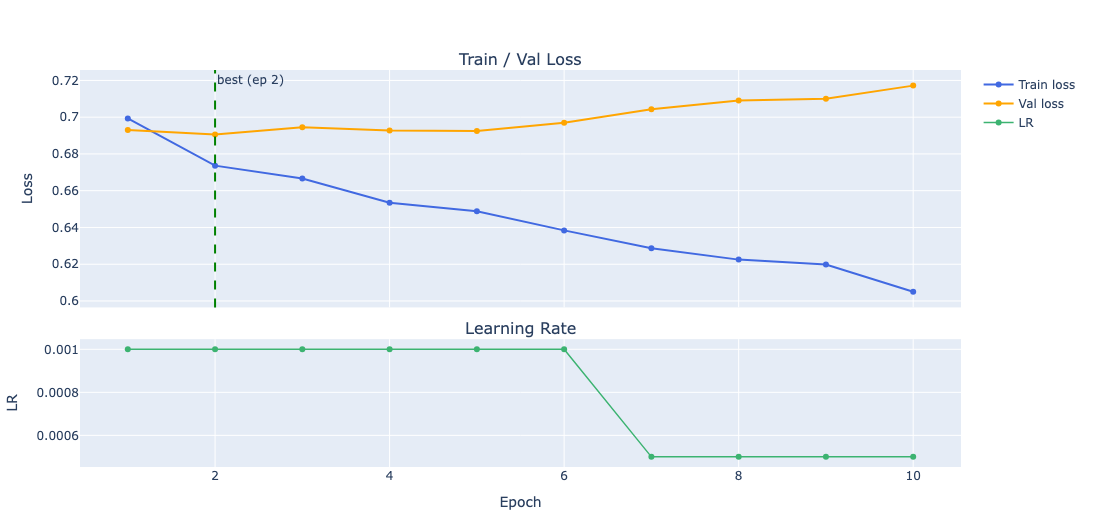

In [20]:
epochs = list(range(1, len(train_losses) + 1))

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.35], vertical_spacing=0.08,
                    subplot_titles=['Train / Val Loss', 'Learning Rate'])

fig.add_trace(go.Scatter(x=epochs, y=train_losses, name='Train loss',
                          line=dict(color='royalblue', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=val_losses, name='Val loss',
                          line=dict(color='orange', width=2)), row=1, col=1)
fig.add_vline(x=best_epoch, line_dash='dash', line_color='green',
               annotation_text=f'best (ep {best_epoch})', row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=lrs, name='LR',
                          line=dict(color='mediumseagreen', width=1.5)), row=2, col=1)

fig.update_yaxes(title_text='Loss', row=1, col=1)
fig.update_yaxes(title_text='LR',   row=2, col=1)
fig.update_xaxes(title_text='Epoch', row=2, col=1)
fig.update_layout(height=520, margin=dict(l=50, r=20, t=70, b=40))
fig.show()

---
## §10 — Evaluation

**Why the test set?**  
Training and validation losses tell you how the model performs on data it has seen (directly or indirectly). The test set was held back entirely and provides an unbiased estimate of real-world performance.

**Classification metrics:**

| Metric | Meaning | Good value |
|---|---|---|
| **Accuracy** | % of predictions correct | > 0.55 for binary financial prediction |
| **Precision** | Of predicted ups, how many were really up | High = fewer false buy signals |
| **Recall** | Of real ups, how many did we catch | High = fewer missed opportunities |
| **F1** | Harmonic mean of precision & recall | Balances precision and recall |

**Confusion matrix:**  
Shows TP/FP/FN/TN counts. An ideal matrix is diagonal (all predictions correct).

**Probability distribution:**  
A well-calibrated model pushes up-predictions toward P=1 and down-predictions toward P=0. A clumped distribution near P=0.5 means the model is uncertain.

In [21]:
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

model.eval()
all_logits, all_actuals = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model(X_b)[TARGET_LABEL].squeeze(1)
        all_logits.extend(out.tolist())
        all_actuals.extend(y_b[:, 0].tolist())

logits    = np.array(all_logits)
actuals   = np.array(all_actuals)
probs     = 1.0 / (1.0 + np.exp(-logits))   # sigmoid
pred_cls  = (probs >= 0.5).astype(int)
actual_cls = (actuals >= 0.5).astype(int)

tp = int(np.sum((pred_cls == 1) & (actual_cls == 1)))
fp = int(np.sum((pred_cls == 1) & (actual_cls == 0)))
fn = int(np.sum((pred_cls == 0) & (actual_cls == 1)))
tn = int(np.sum((pred_cls == 0) & (actual_cls == 0)))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
accuracy  = float(np.mean(pred_cls == actual_cls))

metrics_df = pd.DataFrame([{
    'accuracy':  round(accuracy, 4),
    'precision': round(precision, 4),
    'recall':    round(recall, 4),
    'f1':        round(f1, 4),
    'test_samples': len(pred_cls),
}])
display(metrics_df)

cm_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual Down', 'Actual Up'],
    columns=['Pred Down', 'Pred Up']
)
print('\nConfusion Matrix:')
display(cm_df)

,accuracy,precision,recall,f1,test_samples
0,0.5312,0.6,0.3529,0.4444,64



Confusion Matrix:


,Pred Down,Pred Up
Actual Down,22,8
Actual Up,22,12


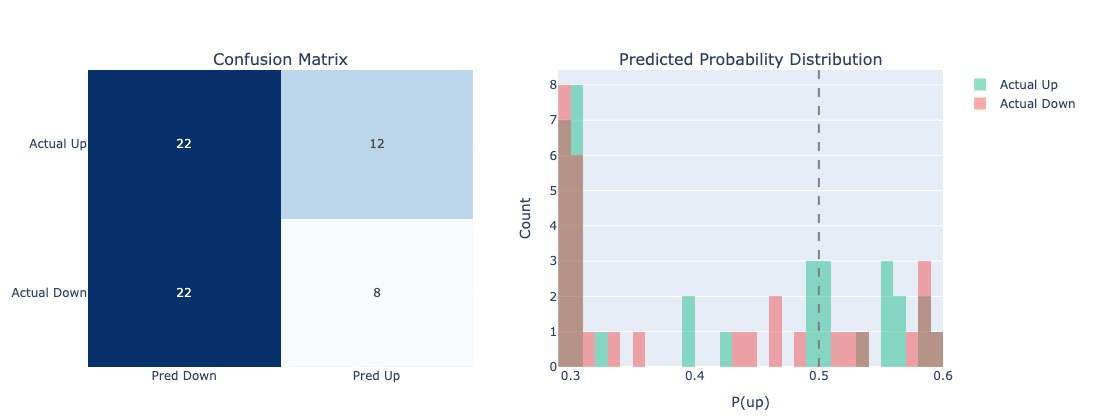


Interpretation:
  Accuracy 53.12% — baseline (always predict majority class): 53.12%
  Model is not better than the naive baseline.


In [22]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Confusion Matrix', 'Predicted Probability Distribution'])

# Confusion matrix heatmap
cm_z    = [[tn, fp], [fn, tp]]
cm_text = [[str(tn), str(fp)], [str(fn), str(tp)]]
fig.add_trace(go.Heatmap(
    z=cm_z,
    x=['Pred Down', 'Pred Up'],
    y=['Actual Down', 'Actual Up'],
    text=cm_text, texttemplate='%{text}',
    colorscale='Blues', showscale=False,
), row=1, col=1)

# Probability histogram by actual class
fig.add_trace(go.Histogram(
    x=probs[actual_cls == 1], name='Actual Up',
    opacity=0.65, nbinsx=40, marker_color='rgba(16,185,129,0.7)',
), row=1, col=2)
fig.add_trace(go.Histogram(
    x=probs[actual_cls == 0], name='Actual Down',
    opacity=0.65, nbinsx=40, marker_color='rgba(239,68,68,0.7)',
), row=1, col=2)
fig.add_vline(x=0.5, line_dash='dash', line_color='gray', row=1, col=2)

fig.update_layout(
    barmode='overlay',
    height=420,
    margin=dict(l=50, r=20, t=70, b=40),
)
fig.update_xaxes(title_text='P(up)', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=2)
fig.show()

print('\nInterpretation:')
print(f'  Accuracy {accuracy:.2%} — baseline (always predict majority class): '
      f'{max(actual_cls.mean(), 1 - actual_cls.mean()):.2%}')
print(f'  Model is {"better" if accuracy > max(actual_cls.mean(), 1-actual_cls.mean()) else "not better"} '
      f'than the naive baseline.')